# IoTSpy — Behavioral Clustering (Sample)

Use **HDBSCAN** density-based clustering to group traffic into behaviorally similar
clusters — without relying on a fixed domain list or pre-labelled data.

Each cluster represents a distinct traffic pattern, e.g.:
- *SDK heartbeat* — frequent small POSTs to a single ad-network endpoint
- *Vendor API sync* — periodic medium-sized bidirectional calls
- *CDN asset fetch* — large GET responses, bursts near session start
- *Telemetry batch* — infrequent large POSTs to third-party analytics

The **noise bucket** (cluster = -1) is especially valuable: unclustered requests are
rare or structurally unique, often the most interesting for investigation.

**Prerequisites:** run `00_generate_sample_data.ipynb` first.

**Optional:** install `umap-learn` for the 2-D scatter visualisation.
```
pip install umap-learn
```

In [1]:
from pathlib import Path
import json, math, re
from collections import Counter
import ipaddress

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
import hdbscan

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130

DATA_PATH = Path("../data/sample_captures.parquet")
assert DATA_PATH.exists(), "Run 00_generate_sample_data.ipynb first"

df = pd.read_parquet(DATA_PATH)
if "timestamp" not in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp_ms"], unit="ms", utc=True)
df["tag_list"]       = df["tags"].apply(json.loads)
df["rule_risk_score"] = df.get("risk_score", pd.Series(np.zeros(len(df)))).fillna(0.0)

# ── column name helpers ───────────────────────────────────────────────────────
def col(a, b): return a if a in df.columns else b
host_col    = col("host",               "Host")
method_col  = col("method",             "Method")
path_col    = col("path",               "Path")
port_col    = col("port",               "Port")
status_col  = col("status_code",        "StatusCode")
tls_col     = col("is_tls",             "IsTls")
cipher_col  = col("tls_cipher_suite",   "TlsCipherSuite")
req_sz_col  = col("request_body_size",  "RequestBodySize")
resp_sz_col = col("response_body_size", "ResponseBodySize")
dur_col     = col("duration_ms",        "DurationMs")
req_h_col   = col("request_headers",    "RequestHeaders")
resp_h_col  = col("response_headers",   "ResponseHeaders")

print(f"Loaded {len(df):,} captures")

Loaded 2,200 captures


## 1  Feature engineering

In [2]:
def shannon_entropy(s: str) -> float:
    if not s: return 0.0
    c, n = Counter(s), len(s)
    return -sum((v/n)*math.log2(v/n) for v in c.values())

WEAK_CIPHERS   = {"rc4", "3des", "des", "null", "export", "anon"}
MODERN_CIPHERS = {"tls_aes_128_gcm", "tls_aes_256_gcm", "chacha20",
                  "ecdhe_rsa_aes_128_gcm", "ecdhe_rsa_aes_256_gcm"}

def cipher_strength(c: str) -> int:
    if not c: return 0
    lc = c.lower()
    if any(w in lc for w in WEAK_CIPHERS):   return 0
    if any(m in lc for m in MODERN_CIPHERS): return 2
    return 1

def parse_headers(h) -> dict:
    if not h or (isinstance(h, float) and math.isnan(h)): return {}
    if isinstance(h, dict): return {k.lower(): v for k, v in h.items()}
    try: return {k.lower(): v for k, v in json.loads(h).items()}
    except Exception: return {}

AD_PATH_RE = re.compile(
    r"/(ad|ads|bid|click|collect|event|telemetry|pixel|beacon|"
    r"impression|rtb|sdk|analytics|log|report|metric|track)",
    re.IGNORECASE,
)

req_hdrs  = df[req_h_col].apply(parse_headers)
resp_hdrs = df[resp_h_col].apply(parse_headers)

feat = pd.DataFrame(index=df.index)
feat["dns_entropy"]         = df[host_col].fillna("").apply(shannon_entropy)
feat["host_len"]            = df[host_col].fillna("").apply(len)
feat["host_depth"]          = df[host_col].fillna("").apply(lambda h: h.count("."))
feat["is_tls"]              = df[tls_col].astype(int)
feat["tls_cipher_strength"] = df[cipher_col].fillna("").apply(cipher_strength)
feat["method_post"]         = (df[method_col] == "POST").astype(int)
feat["method_put"]          = (df[method_col] == "PUT").astype(int)
feat["is_standard_port"]    = df[port_col].isin({80, 443, 8080, 8443}).astype(int)
feat["req_size_log"]        = np.log1p(df[req_sz_col].fillna(0))
feat["resp_size_log"]       = np.log1p(df[resp_sz_col].fillna(0))
feat["duration_log"]        = np.log1p(df[dur_col].clip(lower=0).fillna(0))
feat["has_device_id_hdr"]   = req_hdrs.apply(
    lambda h: int(any("device" in k or "idfa" in k or "idfv" in k for k in h)))
feat["resp_is_json"]        = resp_hdrs.apply(
    lambda h: int("json" in h.get("content-type", "").lower()))
feat["resp_is_binary"]      = resp_hdrs.apply(
    lambda h: int(any(t in h.get("content-type", "").lower()
                      for t in ("octet-stream", "protobuf", "binary", "video", "mp4"))))
feat["path_ad_pattern"]     = df[path_col].fillna("").apply(lambda p: int(bool(AD_PATH_RE.search(p))))
feat["path_len"]            = df[path_col].fillna("").apply(len)
feat["path_depth"]          = df[path_col].fillna("").apply(lambda p: p.count("/"))
feat["has_query_string"]    = df[path_col].fillna("").apply(lambda p: int("?" in p))
feat["status_2xx"]          = ((df[status_col] >= 200) & (df[status_col] < 300)).astype(int)
feat["hour_of_day"]         = df["timestamp"].dt.hour

FEATURE_COLS = feat.columns.tolist()
print(f"{len(FEATURE_COLS)} features ready")

20 features ready


## 2  HDBSCAN clustering

In [3]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(feat[FEATURE_COLS].astype(float))

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    cluster_selection_epsilon=0.3,
    metric="euclidean",
    prediction_data=True,
)
labels = clusterer.fit_predict(X_scaled)
df["cluster"] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_pct  = (labels == -1).mean() * 100
print(f"Found {n_clusters} clusters  |  noise: {noise_pct:.1f}%")

Found 46 clusters  |  noise: 4.7%


## 3  UMAP visualisation (optional)

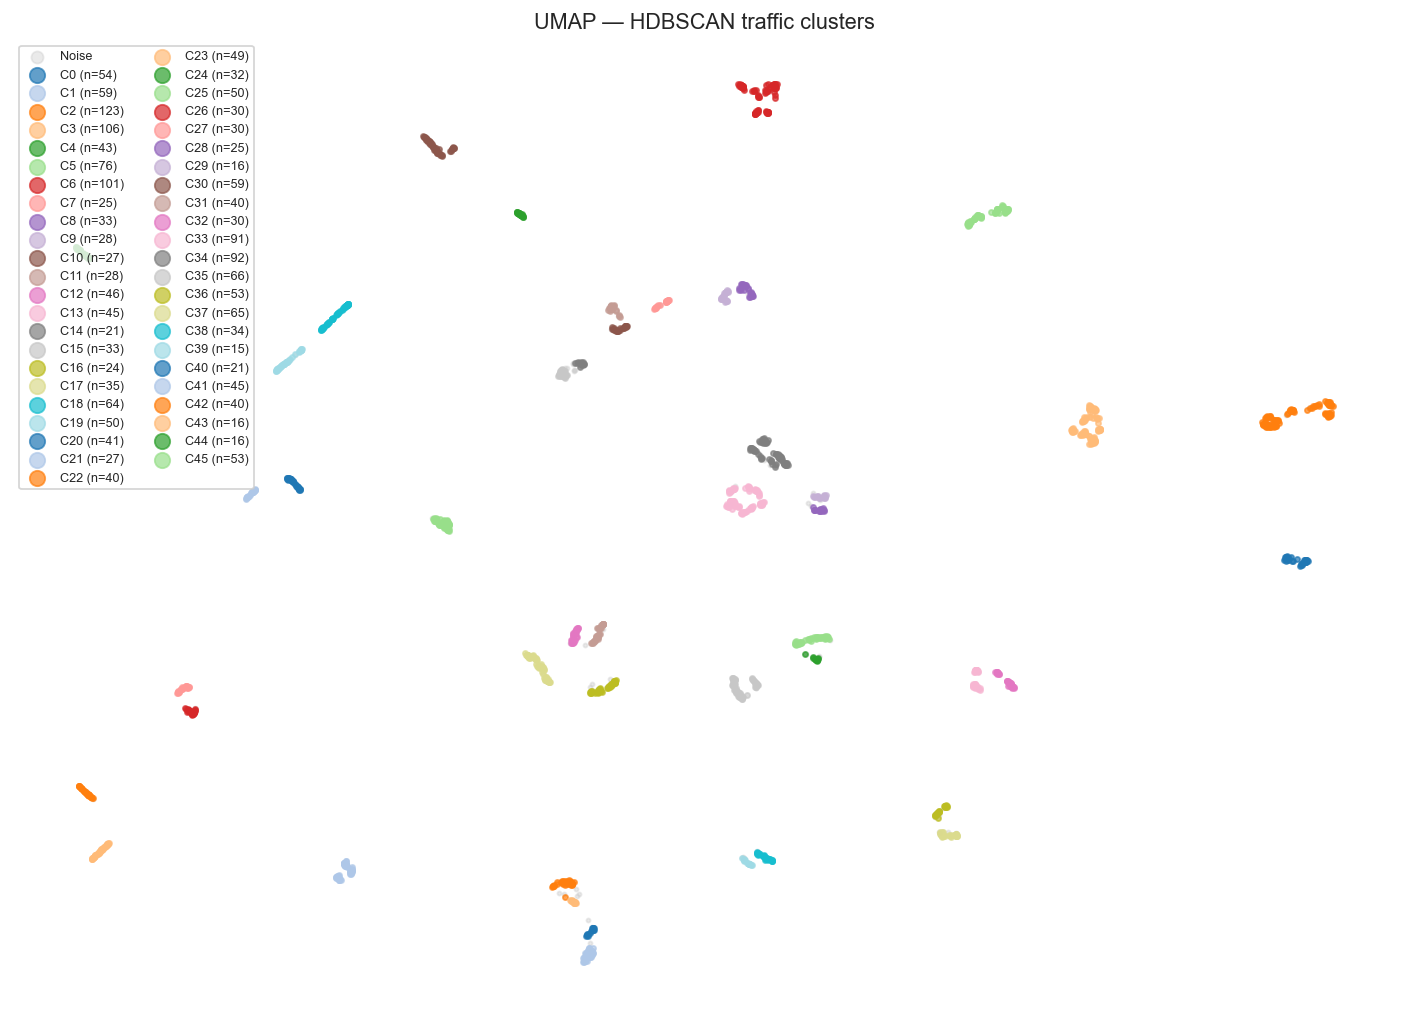

In [4]:
try:
    import umap
    reducer   = umap.UMAP(n_neighbors=20, min_dist=0.1, random_state=42, n_jobs=1)
    embedding = reducer.fit_transform(X_scaled)
    df["umap_x"], df["umap_y"] = embedding[:, 0], embedding[:, 1]

    cmap = plt.colormaps.get_cmap("tab20")

    fig, ax = plt.subplots(figsize=(11, 8))
    noise = df[df["cluster"] == -1]
    ax.scatter(noise["umap_x"], noise["umap_y"],
               c="#cccccc", s=5, alpha=0.4, label="Noise")
    for cid in sorted(set(labels) - {-1}):
        sub = df[df["cluster"] == cid]
        ax.scatter(sub["umap_x"], sub["umap_y"],
                   s=8, alpha=0.7, color=cmap(cid % 20),
                   label=f"C{cid} (n={len(sub)})")
    ax.set_title("UMAP — HDBSCAN traffic clusters")
    ax.legend(markerscale=3, fontsize=7, loc="best", ncol=2)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("umap-learn not installed. Run: pip install umap-learn")
    print("Cluster profile analysis below still works without it.")

## 4  Cluster profiles

In [5]:
profiles = []
for cid in sorted(set(labels) - {-1}):
    sub       = df[df["cluster"] == cid]
    top_host  = sub[host_col].value_counts().index[0]
    dom_meth  = sub[method_col].value_counts().index[0]
    avg_risk  = sub["rule_risk_score"].mean()
    tags_flat = [t for ts in sub["tag_list"] for t in ts]
    top_tags  = ", ".join(k for k, _ in Counter(tags_flat).most_common(2)) or "—"
    cat_col   = "category" if "category" in df.columns else host_col
    top_cat   = sub[cat_col].value_counts().index[0] if cat_col == "category" else ""

    profiles.append({
        "cluster":    cid,
        "size":       len(sub),
        "top_host":   top_host,
        "category":   top_cat,
        "method":     dom_meth,
        "uniq_hosts": sub[host_col].nunique(),
        "avg_req_B":  round(sub[req_sz_col].mean()),
        "avg_resp_B": round(sub[resp_sz_col].mean()),
        "avg_risk":   round(avg_risk, 4),
        "top_tags":   top_tags,
    })

profiles_df = pd.DataFrame(profiles)
pd.set_option("display.max_colwidth", 50)
pd.set_option("display.width", 160)
print(profiles_df.sort_values("size", ascending=False).to_string(index=False))

 cluster  size                         top_host  category method  uniq_hosts  avg_req_B  avg_resp_B  avg_risk                     top_tags
       2   123        cdn.playvault.example.com VendorCDN    GET           2          0     1237208    0.0000                            —
       3   106     updates.example-firmware.com       OTA    GET           2          0         828    0.0000                            —
       6   101   reporting.datalink.example.net Analytics   POST           2       1293         131    0.2465 DataBroker, ExfiltrationRisk
      34    92          api.acme-tv.example.com VendorAPI   POST           6        254         312    0.0000                            —
      33    91        api.playvault.example.com VendorAPI   POST           6        285         200    0.0000                            —
       5    76        time.internal.example.net       NTP    GET           1          0         543    0.0000                            —
      35    66       track.

## 5  Category heatmap per cluster

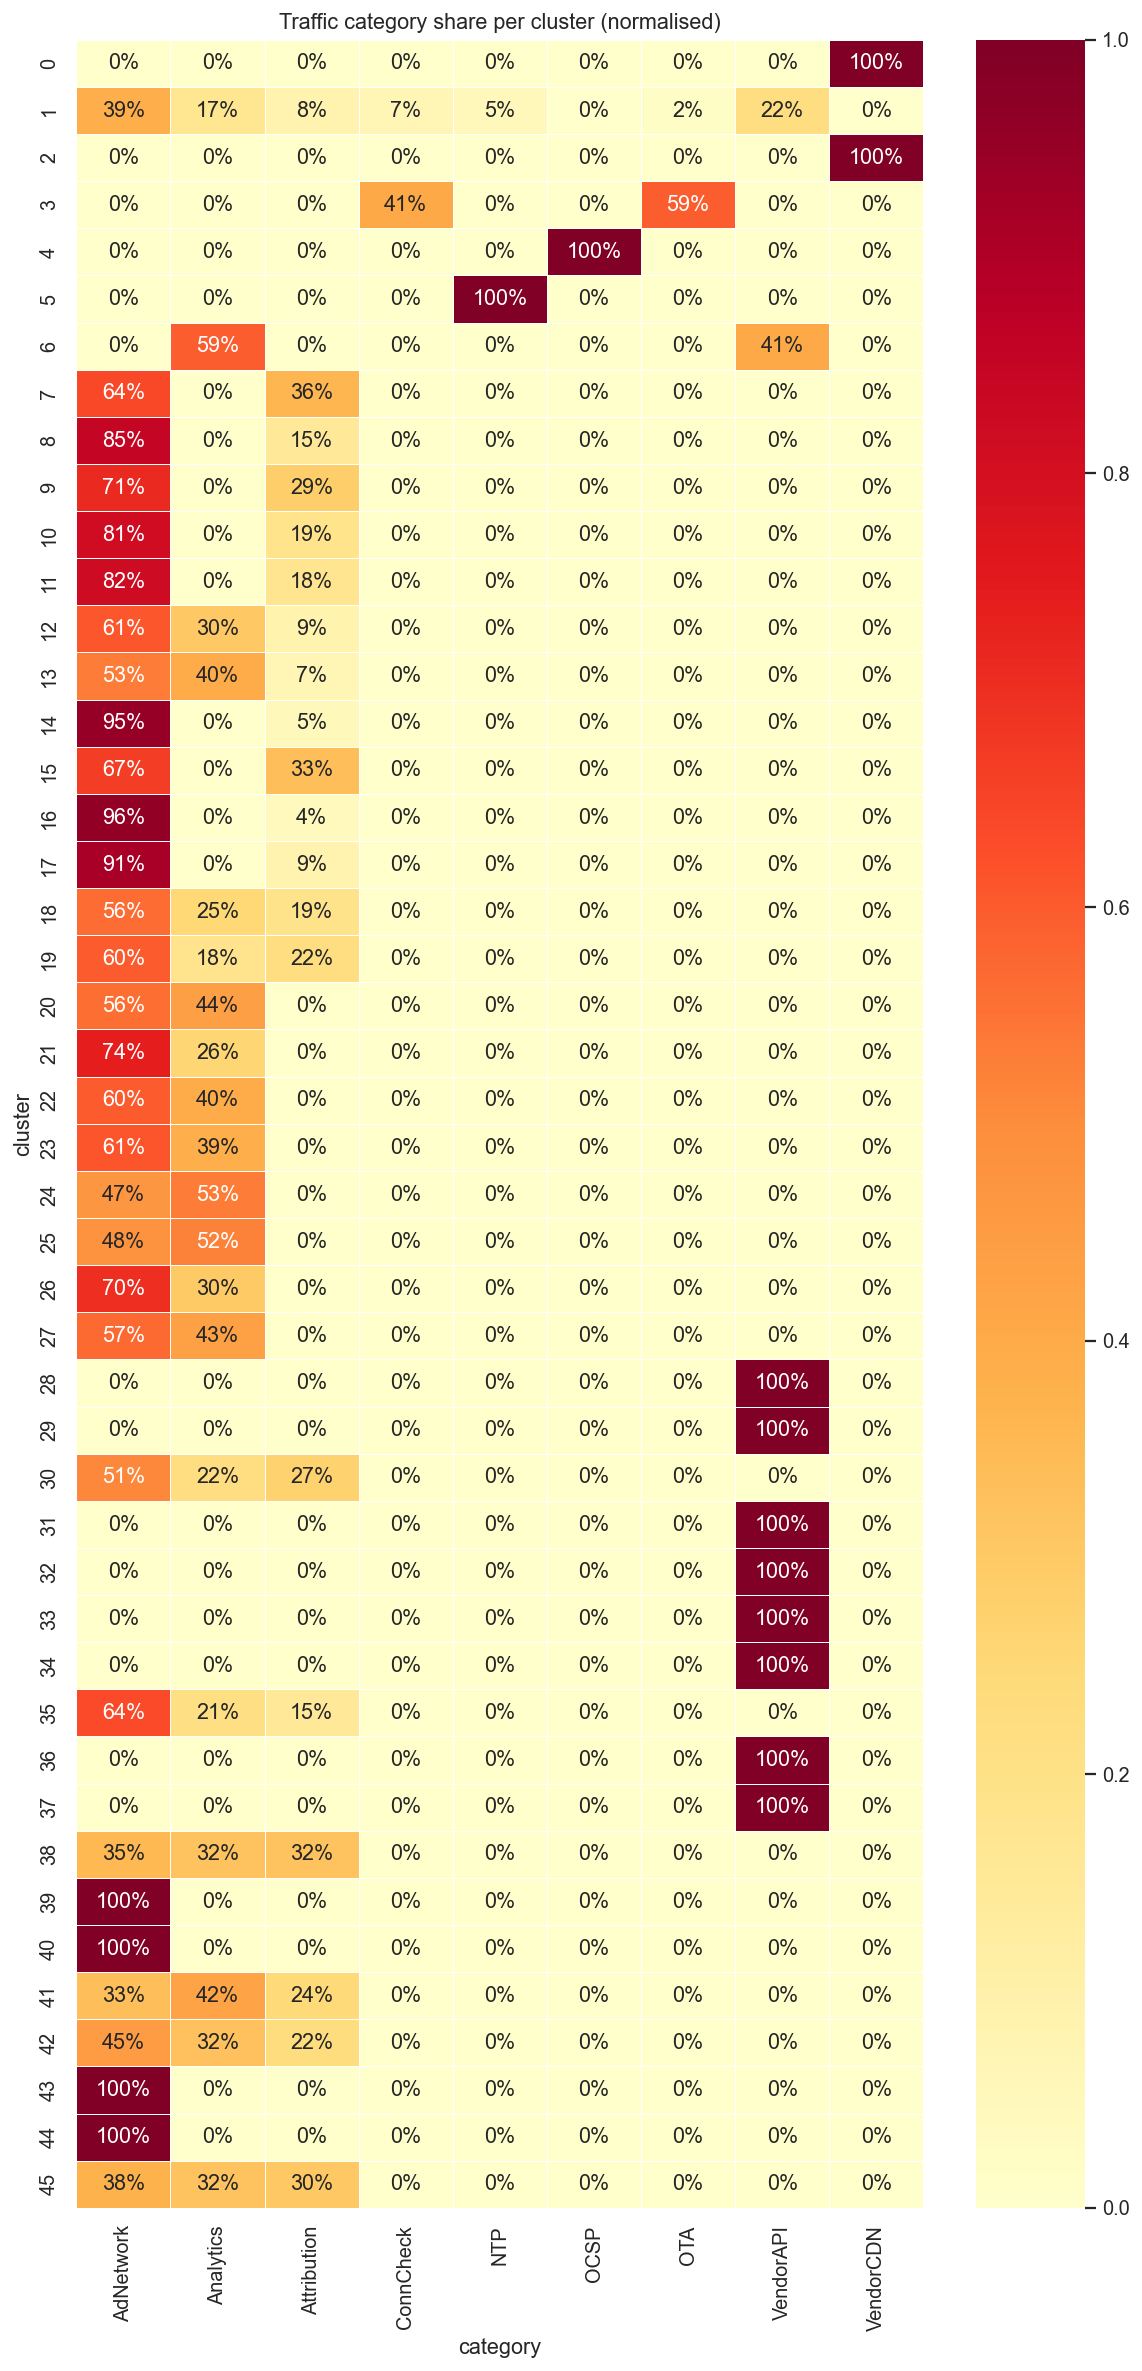

In [6]:
if "category" in df.columns:
    pivot = (
        df[df["cluster"] >= 0]
        .groupby(["cluster", "category"])
        .size()
        .unstack(fill_value=0)
    )
    pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns)), max(4, len(pivot)*0.4)))
    sns.heatmap(pivot_norm, annot=True, fmt=".0%", cmap="YlOrRd",
                linewidths=0.5, ax=ax)
    ax.set_title("Traffic category share per cluster (normalised)")
    plt.tight_layout()
    plt.show()
else:
    print("No 'category' column — heatmap skipped (available in synthetic dataset).")

## 6  Temporal fingerprint

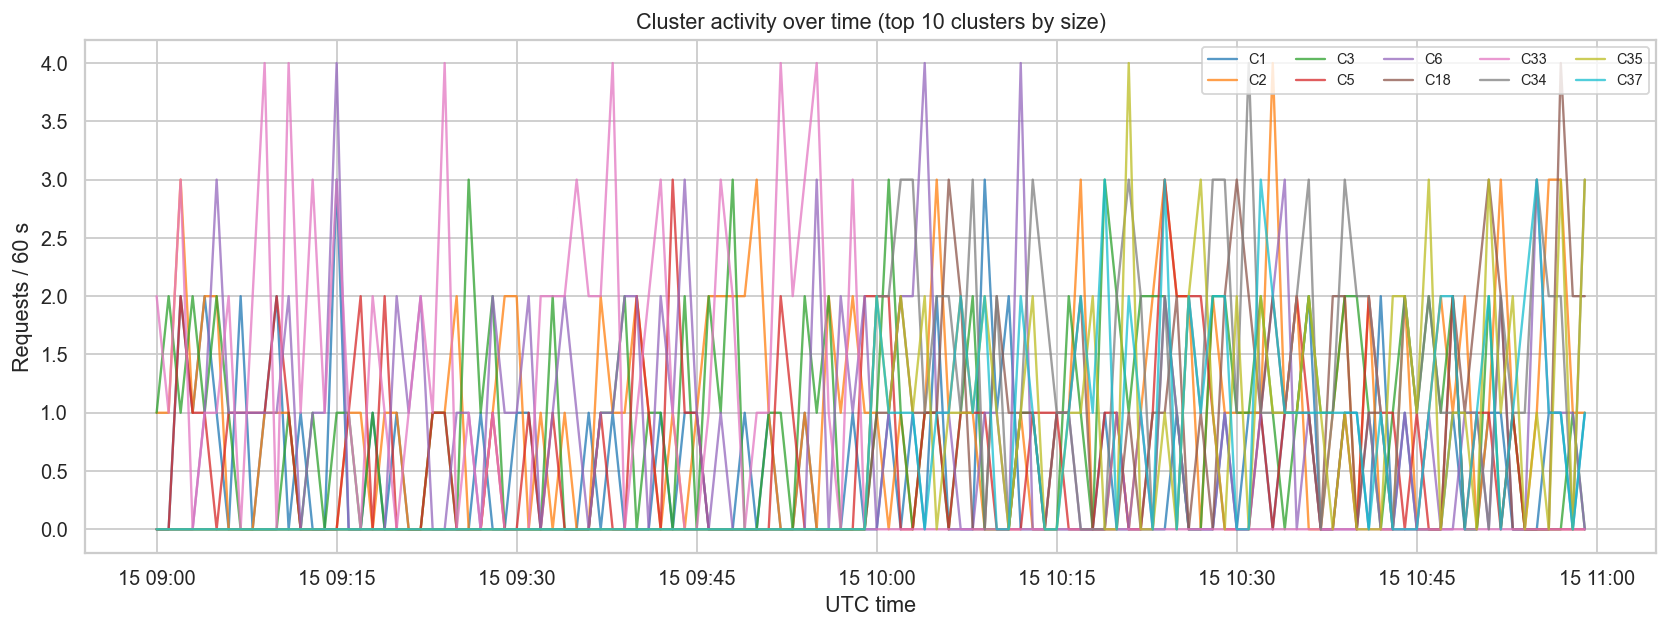

In [7]:
df["bucket"] = df["timestamp"].dt.floor("60s")

# Only plot the top 10 clusters by size to keep the chart readable
top_clusters = profiles_df.nlargest(10, "size")["cluster"].tolist()

timeline = (
    df[df["cluster"].isin(top_clusters)]
    .groupby(["bucket", "cluster"])
    .size()
    .unstack(fill_value=0)
)

cmap2 = plt.colormaps.get_cmap("tab10")
fig, ax = plt.subplots(figsize=(13, 5))
for i, cid in enumerate(timeline.columns):
    ax.plot(timeline.index, timeline[cid],
            label=f"C{cid}", alpha=0.75, linewidth=1.3, color=cmap2(i % 10))
ax.set_xlabel("UTC time")
ax.set_ylabel("Requests / 60 s")
ax.set_title("Cluster activity over time (top 10 clusters by size)")
ax.legend(fontsize=8, ncol=5)
plt.tight_layout()
plt.show()

## 7  Noise bucket

Requests HDBSCAN couldn't assign to any cluster.  
These are structurally unique — rare, one-off calls that rule-based detection may also miss.

In [8]:
noise = df[df["cluster"] == -1]
print(f"Noise bucket: {len(noise):,} requests ({len(noise)/len(df)*100:.1f}%)\n")

print("Top hosts in noise bucket:")
print(noise[host_col].value_counts().head(15).to_string())

tagged_noise = noise[noise["tag_list"].apply(len) > 0]
if len(tagged_noise):
    print(f"\nNoise rows with risk tags ({len(tagged_noise)}):")
    print(tagged_noise[[host_col, method_col, path_col, "tag_list", "rule_risk_score"]]
          .head(15).to_string(index=False))

Noise bucket: 103 requests (4.7%)

Top hosts in noise bucket:
host
bid.rtbfusion.example.com           22
sdk.attribchain.example.com         20
ads.quantumreach.example.net        11
log.behavioriq.example.com           9
track.pixelwave.example.io           8
api.acme-tv.example.com              6
api.watchguard-cam.example.com       5
sync.vocalize-home.example.com       4
collect.insightsdash.example.com     4
api.playvault.example.com            3
cdn.playvault.example.com            3
api.vocalize-home.example.com        3
telemetry.acme-tv.example.com        2
events.quantumreach.example.net      2
p.attribchain.example.com            1

Noise rows with risk tags (77):
                        host method            path                       tag_list  rule_risk_score
   bid.rtbfusion.example.com   POST     /impression                   [DataBroker]              0.4
   bid.rtbfusion.example.com   POST /v3/attribution [ExfiltrationRisk, DataBroker]              0.7
  track.pixelwa

## 8  Persist cluster assignments (optional)

Set `WRITE_TO_DB = True` to write cluster labels into `TrafficInsights.ReviewNote`
so analysts can review cluster context in the IoTSpy dashboard.

In [9]:
WRITE_TO_DB = False
DB_PATH     = Path("../../../../src/IoTSpy.Api/iotspy.db")   # adjust if needed

if WRITE_TO_DB:
    import sqlite3
    assert DB_PATH.exists(), f"DB not found at {DB_PATH}"
    con = sqlite3.connect(DB_PATH)
    updates = [
        (f"hdbscan_cluster={row.cluster}", row.capture_id)
        for row in df[df["cluster"] >= 0].itertuples()
    ]
    con.executemany(
        "UPDATE TrafficInsights SET ReviewNote=? WHERE CaptureId=?",
        updates,
    )
    con.commit()
    con.close()
    print(f"Wrote cluster labels for {len(updates):,} captures.")
else:
    sample = df[df["cluster"] >= 0][["capture_id", "cluster", host_col]].head(8)
    print("Preview (set WRITE_TO_DB=True to persist):")
    print(sample.to_string(index=False))

Preview (set WRITE_TO_DB=True to persist):
                          capture_id  cluster                             host
15f84be2-186c-4dfe-abf3-6fe97a41af53       40        bid.rtbfusion.example.com
d33f915e-99e0-4a1a-861e-22f7c905ecb4       30       log.behavioriq.example.com
e60957ed-de06-4878-b3c0-4e14518621bb        2        cdn.playvault.example.com
ff38bc83-1044-4b3c-b968-851137366ebf       33   sync.vocalize-home.example.com
c22e498d-7aa1-436a-8270-e3677044ec13        7     ads.quantumreach.example.net
eaac0b3c-2b2f-45fe-9091-e15e3f38ed6f        8      sdk.attribchain.example.com
572f856b-d095-48a2-b9f3-59ed44d106a8       22  events.quantumreach.example.net
34684dee-ab22-46ac-a9f3-0c3aff2bcb5e       22 collect.insightsdash.example.com
